In [15]:
import pandas as pd
import numpy as np
import requests
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, classification_report
import matplotlib.pyplot as plt
from sklearn.svm import SVC

In [16]:
# Step 1: Fetch historical weather data (60 days back because api limitation)
start_date = datetime.today().date() - timedelta(days=60)
end_date = datetime.today().date()

lat = -7.9797
lon = 112.6304

url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": lat,
    "longitude": lon,
    "hourly": "temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,cloudcover,weathercode",
    "start_date": start_date.strftime("%Y-%m-%d"),
    "end_date": end_date.strftime("%Y-%m-%d"),
    "timezone": "auto"
}
response = requests.get(url, params=params)
data = response.json()["hourly"]
df = pd.DataFrame(data)
df["time"] = pd.to_datetime(df["time"])
df["hour"] = df["time"].dt.hour
df["day"] = df["time"].dt.dayofweek

In [17]:
df

,time,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,cloudcover,weathercode,hour,day
0,2025-04-30 00:00:00,20.1,93,4.3,0.0,36,1,0,2
1,2025-04-30 01:00:00,19.6,94,5.6,0.0,32,1,1,2
2,2025-04-30 02:00:00,19.2,93,5.4,0.0,21,1,2,2
3,2025-04-30 03:00:00,18.8,91,5.1,0.0,6,0,3,2
4,2025-04-30 04:00:00,18.6,91,5.1,0.0,5,0,4,2
...,...,...,...,...,...,...,...,...,...
1459,2025-06-29 19:00:00,20.5,93,3.2,0.0,73,2,19,6
1460,2025-06-29 20:00:00,20.1,95,3.3,0.0,71,2,20,6
1461,2025-06-29 21:00:00,19.9,96,3.8,0.0,70,45,21,6
1462,2025-06-29 22:00:00,19.8,96,4.0,0.0,69,2,22,6


In [18]:
# Step 2: Split train-test early to prevent leakage
X_base = df[["hour", "day"]]
X_train_base, X_test_base, idx_train, idx_test = train_test_split(
    X_base, df.index, test_size=0.2, random_state=42, shuffle=True)


--- TEMPERATURE_2M Evaluation ---
MAE: 1.75, RMSE: 1.95


d:\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


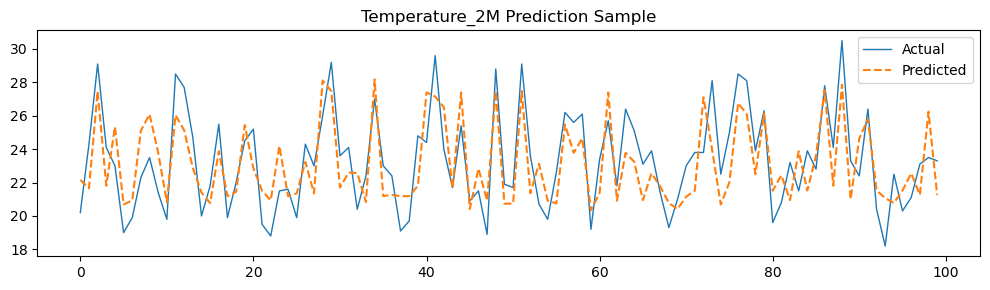


--- RELATIVE_HUMIDITY_2M Evaluation ---
MAE: 4.75, RMSE: 6.39


d:\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


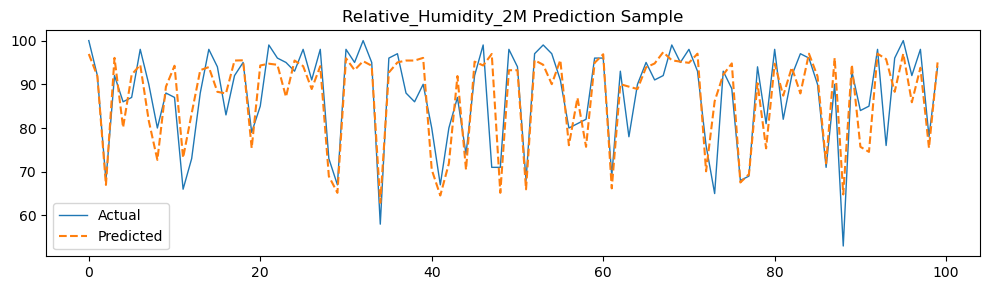


--- WIND_SPEED_10M Evaluation ---
MAE: 1.69, RMSE: 2.23


d:\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


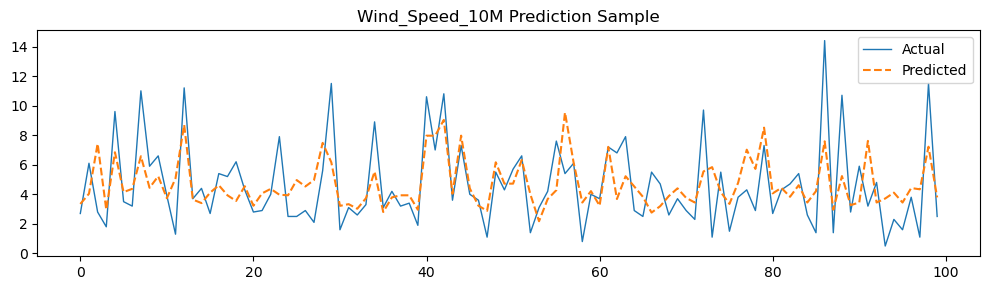


--- CLOUDCOVER Evaluation ---
MAE: 18.28, RMSE: 24.20


d:\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


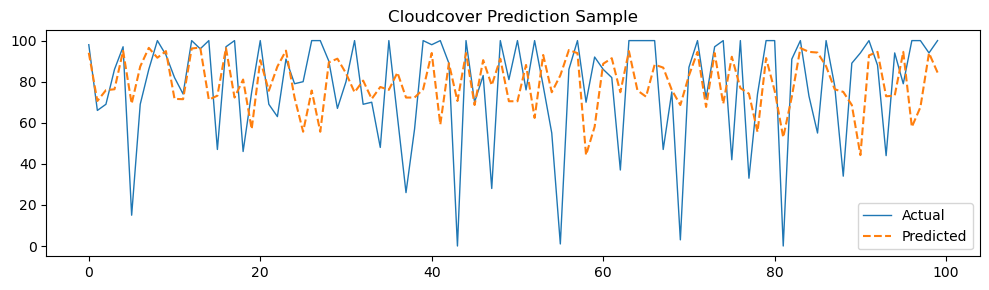

In [19]:
# Step 3: Train regression models for continuous features
features_to_predict = ["temperature_2m", "relative_humidity_2m", "wind_speed_10m", "cloudcover"]
regressors = {}
for feature in features_to_predict:
    y_train = df.loc[idx_train, feature]
    X_train = X_train_base
    model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    model.fit(X_train, y_train)
    regressors[feature] = model

    # Evaluate on test
    y_test = df.loc[idx_test, feature]
    X_test = X_test_base
    y_pred = model.predict(X_test)
    print(f"\n--- {feature.upper()} Evaluation ---")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}, RMSE: {mean_squared_error(y_test, y_pred, squared=False):.2f}")

    # Plot sample
    plt.figure(figsize=(10, 3))
    plt.plot(y_test.values[:100], label="Actual", linewidth=1)
    plt.plot(y_pred[:100], label="Predicted", linestyle="--")
    plt.title(f"{feature.title()} Prediction Sample")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [20]:
# Step 4: Precipitation classification
bins = [-0.1, 0.1, 2, 100]
labels = [0, 1, 2]  # 0=No rain, 1=Light, 2=Heavy
df["precip_class"] = pd.cut(df["precipitation"], bins=bins, labels=labels).astype(int)
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    df[["hour", "day"]], df["precip_class"], test_size=0.2, random_state=42)

precip_model = SVC(C=0.1, class_weight='balanced', coef0= 0.0, degree=2, gamma='auto', kernel='rbf', shrinking=True,  random_state=42)
precip_model.fit(X_train_p, y_train_p)
y_pred_p = precip_model.predict(X_test_p)
print("\n--- PRECIPITATION Classification Report ---")
print(classification_report(y_test_p, y_pred_p))

def map_precip_class_to_value(x):
    return {0: 0.0, 1: 1.0, 2: 5.0}[x]


--- PRECIPITATION Classification Report ---
              precision    recall  f1-score   support

           0       0.96      0.79      0.87       251
           1       0.24      0.28      0.26        40
           2       0.03      0.50      0.05         2

    accuracy                           0.72       293
   macro avg       0.41      0.52      0.39       293
weighted avg       0.86      0.72      0.78       293



In [21]:
# Step 5: Predict weather features for next 7 days
future = pd.date_range(datetime.today(), periods=168, freq="H")
df_future = pd.DataFrame({"time": future})
df_future["hour"] = df_future["time"].dt.hour
df_future["day"] = df_future["time"].dt.dayofweek

# Predict continuous features
for name, model in regressors.items():
    df_future[name] = model.predict(df_future[["hour", "day"]])

# Predict precipitation
df_future["precip_class"] = precip_model.predict(df_future[["hour", "day"]])
df_future["precipitation"] = df_future["precip_class"].apply(map_precip_class_to_value)

C:\Users\BUDI\AppData\Local\Temp\ipykernel_48172\3237145651.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future = pd.date_range(datetime.today(), periods=168, freq="H")


In [22]:
# Step 6: Weathercode classification
X_weather = df[["temperature_2m", "relative_humidity_2m", "wind_speed_10m",
                "precipitation", "cloudcover", "hour", "day"]]
y_weather = df["weathercode"]
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_weather, y_weather, test_size=0.2, random_state=42)
weather_model = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
weather_model.fit(X_train_w, y_train_w)
print("\n--- WEATHERCODE Classification Report ---")
print(classification_report(y_test_w, weather_model.predict(X_test_w)))



--- WEATHERCODE Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       0.92      0.88      0.90        25
           2       0.75      0.89      0.81        46
           3       0.91      0.91      0.91       106
          45       0.94      0.88      0.91        74
          61       0.00      0.00      0.00         2
          80       0.91      0.87      0.89        23
          95       0.91      0.91      0.91        11
          96       0.50      1.00      0.67         1

    accuracy                           0.89       293
   macro avg       0.76      0.81      0.78       293
weighted avg       0.89      0.89      0.89       293



d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [23]:
# Step 7: Predict weathercode
features = ["temperature_2m", "relative_humidity_2m", "wind_speed_10m",
            "precipitation", "cloudcover", "hour", "day"]
df_future["weathercode_pred"] = weather_model.predict(df_future[features])

print("\n--- Prediksi Cuaca 7 Hari ke Depan (contoh) ---")
print(df_future[["time", "temperature_2m", "precipitation", "weathercode_pred"]].head())


--- Prediksi Cuaca 7 Hari ke Depan (contoh) ---
                        time  temperature_2m  precipitation  weathercode_pred
0 2025-06-29 15:14:40.680435       25.124111            5.0                95
1 2025-06-29 16:14:40.680435       24.798019            5.0                96
2 2025-06-29 17:14:40.680435       23.779787            5.0                95
3 2025-06-29 18:14:40.680435       23.136555            5.0                95
4 2025-06-29 19:14:40.680435       22.019073            1.0                80


In [24]:
df_future['weathercode_pred'].value_counts()

weathercode_pred
2     71
45    32
95    22
96    18
3     18
80     7
Name: count, dtype: int64

In [ ]:
# def map_weathercode(code):
#     if code == 0:
#         return "Cerah"
#     elif code in [1, 2, 3]:
#         return "Berawan"
#     elif code in [45, 48]:
#         return "Berkabut"
#     elif code in [51, 53, 55, 80]:
#         return "Hujan Ringan"
#     elif code in [61, 63, 65, 81, 82]:
#         return "Hujan Deras"
#     elif code in [95, 96, 99]:
#         return "Hujan Petir"
#     else:
#         return "Lainnya"
def map_weathercode(code):
    if   code == 0:
        return "Cerah 🌞"
    elif code in [1, 2, 3]:
        return "Berawan ☁️"
    elif code in [45, 48]:
        return "Berkabut"
    elif code in [51, 53, 55, 56, 57]:  
        return "Gerimis 💧"
    elif code in [61, 63, 65, 80]:
        return "Hujan Ringan 🌦️"
    elif code in [66, 67, 81, 82]:
        return "Hujan Deras 🌧️"
    elif code in [71, 73, 75, 85, 86, 77]: 
        return "Bersalju ❄️"
    elif code in [95, 96, 99]:
        return "Hujan Petir ⛈️"
    else:
        return "Lainnya"
    
# Map weathercode to human-readable format
df_future['weather_pred'] = df_future['weathercode_pred'].apply(map_weathercode)

In [26]:
df_future['weather_pred'].value_counts()

weather_pred
Berawan ☁️         89
Hujan Petir ⛈️     40
Berkabut           32
Hujan Ringan 🌦️     7
Name: count, dtype: int64

In [27]:
df_future

,time,hour,day,temperature_2m,relative_humidity_2m,wind_speed_10m,cloudcover,precip_class,precipitation,weathercode_pred,weather_pred
0,2025-06-29 15:14:40.680435,15,6,25.124111,83.328194,8.701795,96.161158,2,5.0,95,Hujan Petir ⛈️
1,2025-06-29 16:14:40.680435,16,6,24.798019,83.891865,7.527260,94.970130,2,5.0,96,Hujan Petir ⛈️
2,2025-06-29 17:14:40.680435,17,6,23.779787,89.462681,5.220499,94.889148,2,5.0,95,Hujan Petir ⛈️
3,2025-06-29 18:14:40.680435,18,6,23.136555,91.409549,4.324636,91.885378,2,5.0,95,Hujan Petir ⛈️
4,2025-06-29 19:14:40.680435,19,6,22.019073,94.782252,3.348942,92.145591,1,1.0,80,Hujan Ringan 🌦️
...,...,...,...,...,...,...,...,...,...,...,...
163,2025-07-06 10:14:40.680435,10,6,27.102912,70.088582,5.546027,67.719021,0,0.0,2,Berawan ☁️
164,2025-07-06 11:14:40.680435,11,6,27.472332,66.981109,7.421381,75.857982,0,0.0,2,Berawan ☁️
165,2025-07-06 12:14:40.680435,12,6,28.417206,64.052992,6.167817,83.394922,0,0.0,3,Berawan ☁️
166,2025-07-06 13:14:40.680435,13,6,27.477550,65.169675,6.164291,91.201107,1,1.0,95,Hujan Petir ⛈️
